In [100]:
from neural_priors.utils.data import Subject, get_all_subject_ids
import seaborn as sns
import pandas as pd
import matplotlib.pyplot as plt
import os
import os.path as op
from pathlib import Path

subjects = get_all_subject_ids()

df = []
for subject in subjects:
    sub = Subject(subject)
    df.append(sub.get_behavioral_data(add_info=True))

df = pd.concat(df)

In [101]:
bids_folder = Path('/data/ds-neuralpriors')

if not os.path.exists(bids_folder / 'derivatives' / 'figures' / 'figure1'):
    os.makedirs(bids_folder / 'derivatives' / 'figures' / 'figure1')

fig_folder = bids_folder / 'derivatives' / 'figures' / 'figure1'

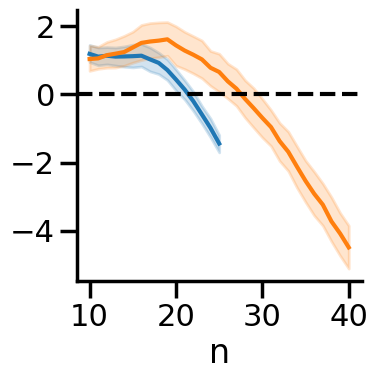

In [45]:
sns.set_context('poster')
tmp = df.groupby(['subject', 'range', 'n'])['error'].mean().groupby(['subject', 'range']).apply(lambda d: d.rolling(5, min_periods=1).mean().droplevel([0,1]))

g = sns.relplot(x='n', y='error', hue='range', data=tmp.reset_index(), kind='line', legend=False)

g.set(ylabel=None, xticks=[10, 20, 30, 40])
g.map(plt.axhline, y=0, ls='--', c='k')

# g.fig.suptitle('Average bias (rolling mean, window=5)', y=1.05)

# Make sure figure is exactl 3 x 3 inches
g.fig.set_size_inches(4, 4)
plt.savefig(fig_folder / 'figure1_bias.pdf', dpi=300, bbox_inches='tight')

In [65]:
import pingouin as pg

diff = tmp.loc[(slice(None), slice(None), slice(10, 25))].abs().groupby(['subject', 'range']).mean()

# diff = diff.xs('wide', level='range') - diff.xs('narrow', level='range') 


pg.ttest(diff.xs('wide', level='range'), diff.xs('narrow', level='range'), paired=True, alternative='greater', correction=False)


/Users/gdehol/mambaforge/envs/neural_priors/lib/python3.9/site-packages/scipy/stats/_continuous_distns.py:6832: RuntimeWarning: overflow encountered in _nct_sf
  return np.clip(_boost._nct_sf(x, df, nc), 0, 1)


,T,dof,alternative,p-val,CI95%,cohen-d,BF10,power
T-test,4.128415,38,greater,0.000096,"[0.28, inf]",0.577976,270.027,0.971234


In [66]:
rolling_window = 5
df_std = df.groupby(['subject', 'range', 'n'], as_index=True)['response'].std().groupby(['subject', 'range']).apply(lambda d: d.rolling(rolling_window, min_periods=1).mean().droplevel([0, 1]))

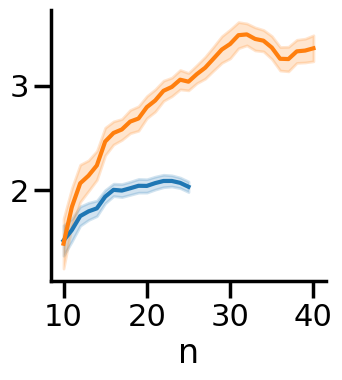

In [67]:
g = sns.relplot(x='n', y='response', hue='range', data=df_std.reset_index(), kind='line', errorbar='se', legend=False)

g.set(ylabel=None, xticks=[10, 20, 30, 40])

# g.set_titles('Standard deviation of responses')

g.fig.set_size_inches(4, 4)

plt.savefig(fig_folder / 'figure1_std.pdf', dpi=300, bbox_inches='tight')

In [68]:
# Do the t-test for the standard deviation
diff_std = df_std.loc[(slice(None), slice(None), slice(10, 25))].abs().groupby(['subject', 'range']).mean()
# diff_std = diff_std.xs('wide', level='range') - diff_std.xs('narrow', level='range')
pg.ttest(diff_std.xs('wide', level='range'), diff_std.xs('narrow', level='range'), paired=True, alternative='greater', correction=False)


/Users/gdehol/mambaforge/envs/neural_priors/lib/python3.9/site-packages/scipy/stats/_continuous_distns.py:6832: RuntimeWarning: overflow encountered in _nct_sf
  return np.clip(_boost._nct_sf(x, df, nc), 0, 1)


,T,dof,alternative,p-val,CI95%,cohen-d,BF10,power
T-test,7.270261,38,greater,5.313708e-09,"[0.46, inf]",1.182351,2.431e+06,1.0


/var/folders/d4/cpqhwlbn301clph1qk64k01nmjkty3/T/ipykernel_46170/432799466.py:34: UserWarning: Tight layout not applied. The bottom and top margins cannot be made large enough to accommodate all Axes decorations.
  plt.tight_layout()


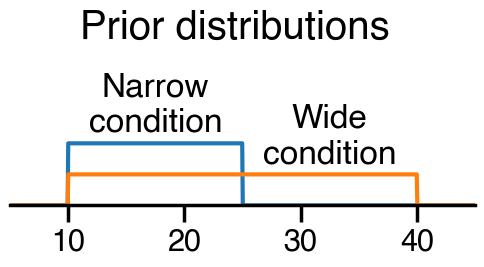

In [113]:
import scipy.stats as ss
import numpy as np

# Set font family to helvetica
plt.rcParams['font.family'] = 'Helvetica'

x = np.linspace(0, 50, 1000)

dist1 = ss.uniform(loc=10, scale=15)
dist2 = ss.uniform(loc=10, scale=30)



plt.plot(x, dist1.pdf(x), label='Uniform')
plt.plot(x, dist2.pdf(x), label='Uniform')

plt.yticks([])
sns.despine(left=True)

plt.gcf().set_size_inches(6, 2.25)

plt.ylim(0, None)

plt.xticks([10, 20, 30, 40])
plt.xlim(5, 45)

plt.text(dist1.mean(), dist1.pdf(dist1.mean()) + 0.005, 'Narrow\ncondition', ha='center', va='bottom')
plt.text((40+25)/2., dist2.pdf(dist2.mean()) + 0.005, 'Wide\ncondition', ha='center', va='bottom')


plt.suptitle('Prior distributions')
plt.subplots_adjust(top=.4)  # Adjust title position

plt.tight_layout()

plt.savefig(fig_folder / 'figure1_priors.pdf', dpi=300, bbox_inches='tight')

# Theory

[(0.12156862745098039, 0.4666666666666667, 0.7058823529411765),
 (1.0, 0.4980392156862745, 0.054901960784313725),
 (0.17254901960784313, 0.6274509803921569, 0.17254901960784313),
 (0.8392156862745098, 0.15294117647058825, 0.1568627450980392),
 (0.5803921568627451, 0.403921568627451, 0.7411764705882353),
 (0.5490196078431373, 0.33725490196078434, 0.29411764705882354),
 (0.8901960784313725, 0.4666666666666667, 0.7607843137254902),
 (0.4980392156862745, 0.4980392156862745, 0.4980392156862745),
 (0.7372549019607844, 0.7411764705882353, 0.13333333333333333),
 (0.09019607843137255, 0.7450980392156863, 0.8117647058823529)]

7.0 7.0
10.0 10.0
13.0 16.0
16.0 22.0
19.0 28.0
22.0 34.0
25.0 40.0


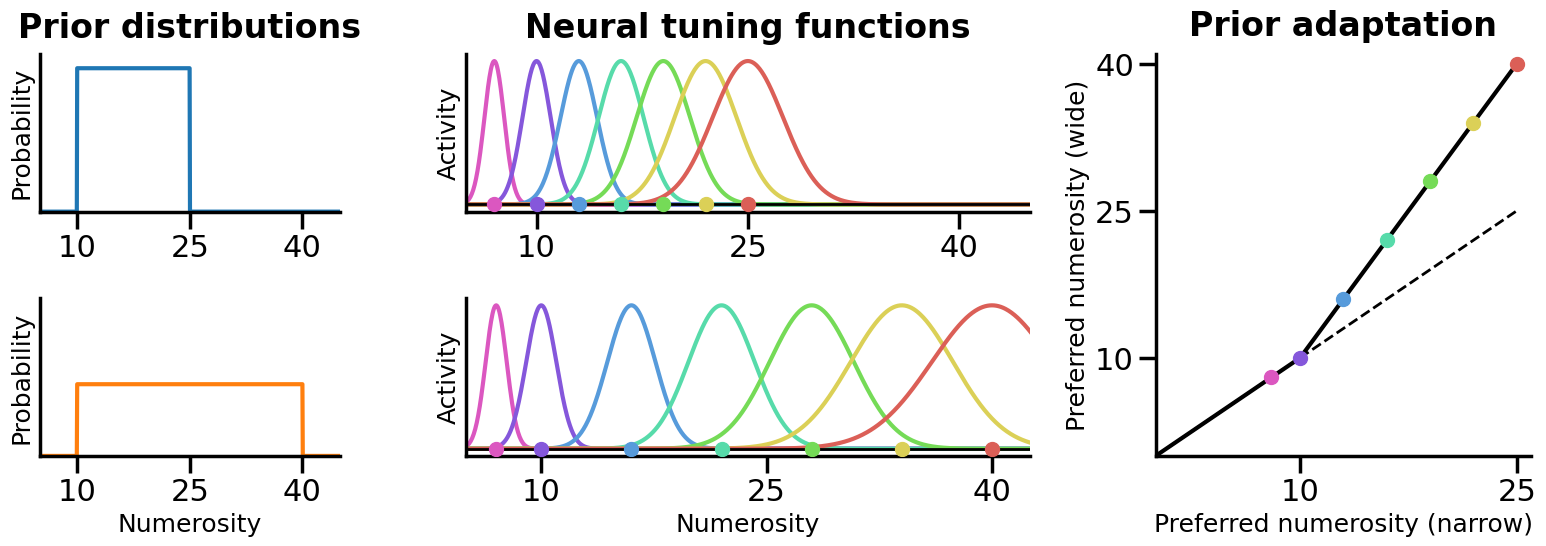

In [126]:
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import uniform
import numpy as np
from matplotlib.gridspec import GridSpec
import scipy.stats as ss

sns.set_context('poster')

# Make sure all xlabels and ylabels have font size 16
plt.rcParams['axes.labelsize'] = 18

#Make axes titles BOLD
plt.rcParams['axes.titleweight'] = 'bold'


palette = sns.color_palette()

# Create a GridSpec with 2 rows and 3 columns, where the second column is twice as wide as the first
fig = plt.figure(figsize=(16, 6))
gs = GridSpec(2, 3, width_ratios=[.8, 1.5, 1], height_ratios=[1, 1], figure=fig)

# Create subplots using the GridSpec
axs = [fig.add_subplot(gs[0, 0]), fig.add_subplot(gs[1, 0]), fig.add_subplot(gs[0, 1]), fig.add_subplot(gs[1, 1]),
       fig.add_subplot(gs[:, 2])]
# axs[4].set_aspect('equal')

# priors
prior_narrow = uniform(loc=10, scale=15)
prior_wide = uniform(loc=10, scale=30)
x = np.linspace(0, 50, 1000)

plt.sca(axs[0])
plt.title('Prior distributions', y=1.05)
plt.plot(x, prior_narrow.pdf(x), label='Narrow', color=palette[0])
plt.yticks([])
plt.xticks([10, 25, 40])
plt.ylabel('Probability')
plt.ylim(0, 1.1 * 1./15.)
plt.xlim(5, 45)

plt.sca(axs[1])
plt.plot(x, prior_wide.pdf(x), label='Wide', color=palette[1])
plt.yticks([])
plt.xlabel('Numerosity')
plt.ylabel('Probability')
plt.xticks([10, 25, 40])
plt.ylim(0, 1.1 * 1./15.)
plt.xlim(5, 45)

plt.sca(axs[2])
plt.title('Neural tuning functions', y=1.05)
plt.ylabel('Activity')
plt.yticks([])

# mus1 = np.linspace(8, 25, 6)
mus1 = [5, 10, 15, 20, 25]
mus1 = np.linspace(7, 25, 7)
# mus1 = np.arange(5, 26, 5)
palette = sns.color_palette("hls", len(mus1))[::-1]

for i, mu in enumerate(mus1):
    plt.plot(x, ss.norm(mu, mu/10).pdf(x) * (mu/10), label=f'{mu}', color=palette[i])
    plt.scatter(mu, 0, color=palette[i], s=100, lw=1, zorder=10)

plt.axhline(0, color='k', lw=2, ls='-', zorder=9)    
plt.xticks([10, 25, 40])
plt.xlim(5, 45)

plt.sca(axs[3])

# for i, mu in enumerate(mus2):
#     plt.plot(x, ss.norm(mu, mu/10).pdf(x) * mu/10., label=f'{mu}', color=palette[i])

for i, mu in enumerate(mus1):

    mu_ = mu if mu < 10 else (mu - 10) * 2 + 10
    plt.plot(x, ss.norm(mu_, mu_/10).pdf(x) * mu_/10., label=f'{mu}', color=palette[i])

    print(mu, mu_)

    plt.scatter(mu_, 0, color=palette[i], s=100, lw=1, zorder=10)

plt.axhline(0, color='k', lw=2, ls='-', zorder=9)    

plt.yticks([])
plt.xticks([10, 25, 40])
plt.xlabel('Numerosity')
plt.ylabel('Activity')
plt.xlim(5, 42.5)

plt.sca(axs[4])
plt.plot([0, 10], [0, 10], color='k', lw=2, ls='--')

plt.scatter(8, 8, color=palette[0], s=100, lw=1, zorder=10)

for i, mu1 in enumerate(mus1):
    mu2 = mu1 if mu1 < 10 else (mu1 - 10) * 2 + 10
    if i > 0:
        plt.scatter(mu1, mu2, color=palette[i], s=100, lw=1, zorder=10)

plt.plot([10, 25], [10, 40], color='k')
plt.plot([0, 10], [0, 10], color='k')

plt.xlim(0, 26)
plt.ylim(0, 41)

plt.xlabel('Preferred numerosity (narrow)')
plt.ylabel('Preferred numerosity (wide)')
plt.xticks([10, 25])
plt.yticks([10, 25, 40])
plt.title("Prior adaptation", y=1.025)
plt.plot([10, 25], [10, 25], color='k', lw=2, ls='--')

sns.despine()
plt.tight_layout()

plt.savefig(fig_folder / 'figure1_priors.pdf', dpi=300, bbox_inches='tight')

array([ 7., 10., 13., 16., 19., 22., 25.])